# Commentary Evaluation Pipeline (LLM-as-a-Judge)

**Two stages:**
1. **Generation** — Generate NL move commentary (with or without engine info)
2. **Evaluation** — Tool-augmented atom-level judge:
   - **Decompose** candidate into atomic claims
   - **Verify** each atom against the board (tool-augmented)
   - **Match** candidate atoms to gold atoms
   - **Quality check** — does the explanation correctly assess move quality?

**Inputs:** `data/review_accepted.jsonl` (gold atoms), `data/review_demo.jsonl` (few-shot demos)

**Metrics:** Factual Precision, Recall (gold coverage), Quality correctness

---
## Setup & Data Loading

In [1]:
import json
import os
import math
import random
import numpy as np
import chess
import chess.engine
import chess.svg
from IPython.display import display, SVG, Markdown, HTML
from dotenv import load_dotenv
from dataclasses import dataclass

load_dotenv()

STOCKFISH_PATH = '/opt/homebrew/bin/stockfish'
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'evaluation', 'data', 'logical_chess_atomize')

K = 0.00368208


def cp_to_winpct(cp):
    """Lichess win% formula."""
    return 50 + 50 * math.tanh(K * cp / 2)


def get_engine_analysis(fen, move_uci=None, depth=22, multipv=3):
    """Get Stockfish top lines. If move_uci given and not in top-N, fetch separately."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=depth), multipv=multipv)
        lines = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:8]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                eval_str = f'M{mate}' if mate is not None else f'{cp/100:+.2f}'
                lines.append({
                    'move_uci': pv[0].uci(), 'move_san': board.san(pv[0]),
                    'eval': eval_str, 'pv_san': ' '.join(san_moves),
                    'cp': cp, 'mate': mate, 'is_top': True,
                })

        if move_uci is not None:
            if not any(l['move_uci'] == move_uci for l in lines):
                move_obj = chess.Move.from_uci(move_uci)
                move_san = board.san(move_obj)
                b2 = board.copy()
                b2.push(move_obj)
                info2 = engine.analyse(b2, chess.engine.Limit(depth=depth))
                sc2 = info2['score'].white()
                cp2 = sc2.score(mate_score=10000)
                mate2 = sc2.mate()
                eval2 = f'M{mate2}' if mate2 is not None else f'{cp2/100:+.2f}'
                pv2 = info2.get('pv', [])
                pv_sans = [move_san]
                b3 = b2.copy()
                for m in pv2[:7]:
                    pv_sans.append(b3.san(m))
                    b3.push(m)
                lines.append({
                    'move_uci': move_uci, 'move_san': move_san,
                    'eval': eval2, 'pv_san': ' '.join(pv_sans),
                    'cp': cp2, 'mate': mate2, 'is_top': False,
                })

    return lines


print(f'Data dir: {DATA_DIR}')

Data dir: /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/logical_chess_atomize


In [2]:
ACCEPTED_PATH = os.path.join(DATA_DIR, 'test_accepted.jsonl')
DEMO_PATH = os.path.join(DATA_DIR, 'review_demo.jsonl')

with open(ACCEPTED_PATH) as f:
    accepted_positions = [json.loads(line) for line in f]

with open(DEMO_PATH) as f:
    review_demos = [json.loads(line) for line in f]

# Raw entries for find_entry()
# with open(os.path.join(DATA_DIR, 'logical_chess_optimal_move.jsonl')) as f:
#     optimal_moves = [json.loads(line) for line in f]
# with open(os.path.join(DATA_DIR, 'logical_chess_other_move.jsonl')) as f:
#     other_moves = [json.loads(line) for line in f]
# _all_raw = optimal_moves + other_moves

# def find_entry(fen, move_uci):
#     for e in _all_raw:
#         if e['fen'] == fen and e['move_uci'] == move_uci:
#             return e
#     raise ValueError(f'Not found: {fen} {move_uci}')

print(f'Accepted positions: {len(accepted_positions)}')
print(f'Demo positions: {len(review_demos)}')
# print(f'Raw entries: {len(_all_raw)}')

Accepted positions: 50
Demo positions: 5


---
## Chess Tools & API Abstraction

In [3]:
import json as _json

def tool_get_legal_moves(fen):
    board = chess.Board(fen)
    moves = [board.san(m) for m in board.legal_moves]
    return _json.dumps({"moves": moves, "count": len(moves)})

def tool_get_piece_at(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"square": square, "piece": "empty"})
    color = "white" if p.color == chess.WHITE else "black"
    return _json.dumps({"square": square, "piece": f"{color} {chess.piece_name(p.piece_type)}"})

def tool_get_attacks(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    attacks = sorted([chess.square_name(a) for a in board.attacks(sq)])
    return _json.dumps({"piece": p.symbol(), "square": square, "attacks": attacks})

def tool_get_attackers(fen, square, color):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    c = chess.WHITE if color == "white" else chess.BLACK
    attackers = [[chess.piece_name(board.piece_at(a).piece_type), chess.square_name(a)]
                 for a in board.attackers(c, sq)]
    return _json.dumps({"square": square, "color": color, "attackers": attackers})

def tool_count_attackers_defenders(fen, square):
    """Count attackers and defenders of a square for both colors."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    piece = board.piece_at(sq)
    
    white_attackers = [[chess.piece_name(board.piece_at(a).piece_type), 
                        chess.square_name(a)]
                       for a in board.attackers(chess.WHITE, sq)]
    black_attackers = [[chess.piece_name(board.piece_at(a).piece_type), 
                        chess.square_name(a)]
                       for a in board.attackers(chess.BLACK, sq)]
    
    result = {
        "square": square,
        "occupant": f"{('white' if piece.color == chess.WHITE else 'black')} {chess.piece_name(piece.piece_type)}" if piece else "empty",
        "white_attackers": {"count": len(white_attackers), "pieces": white_attackers},
        "black_attackers": {"count": len(black_attackers), "pieces": black_attackers},
    }
    
    if piece:
        # Defenders are same-color attackers
        if piece.color == chess.WHITE:
            result["defenders"] = {"count": len(white_attackers), "pieces": white_attackers}
            result["attackers"] = {"count": len(black_attackers), "pieces": black_attackers}
        else:
            result["defenders"] = {"count": len(black_attackers), "pieces": black_attackers}
            result["attackers"] = {"count": len(white_attackers), "pieces": white_attackers}
    
    return _json.dumps(result)

def tool_check_ray_alignment(square_a, square_b):
    """Check if two squares are aligned on a ray (rank/file/diagonal)."""
    sq_a = chess.parse_square(square_a)
    sq_b = chess.parse_square(square_b)
    
    result = {"square_a": square_a, "square_b": square_b, "aligned": False}
    
    # Same square
    if sq_a == sq_b:
        result["aligned"] = True
        result["ray_type"] = "same_square"
        return _json.dumps(result)
    
    # Check rank
    if chess.square_rank(sq_a) == chess.square_rank(sq_b):
        result["aligned"] = True
        result["ray_type"] = "rank"
        result["rank"] = chess.square_rank(sq_a)
        return _json.dumps(result)
    
    # Check file
    if chess.square_file(sq_a) == chess.square_file(sq_b):
        result["aligned"] = True
        result["ray_type"] = "file"
        result["file"] = chess.file_name(chess.square_file(sq_a))
        return _json.dumps(result)
    
    # Check diagonal
    if abs(chess.square_file(sq_a) - chess.square_file(sq_b)) == \
       abs(chess.square_rank(sq_a) - chess.square_rank(sq_b)):
        result["aligned"] = True
        result["ray_type"] = "diagonal"
        return _json.dumps(result)
    
    return _json.dumps(result)

def tool_is_pinned(fen, square):
    """Check if a piece is pinned. Returns pinner and pinned-to piece details."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    pinned = board.is_pinned(p.color, sq)
    result = {"square": square, "pinned": pinned}
    if pinned:
        pin_mask = board.pin(p.color, sq)
        pin_squares = [chess.square_name(s) for s in chess.SquareSet(pin_mask)]
        result["pin_ray"] = pin_squares

        # Identify pinner and pinned-to piece
        # The pin ray includes: pinner, pinned piece, and pinned-to piece
        # Find the attacker (pinner) and the protected piece (pinned-to)
        pinner = None
        pinned_to = None
        for s in chess.SquareSet(pin_mask):
            sq_name = chess.square_name(s)
            piece = board.piece_at(s)
            if piece and s != sq:
                if piece.color != p.color:
                    # Enemy piece on the ray = pinner
                    pinner = {"square": sq_name, "piece": f"{chess.piece_name(piece.piece_type)}"}
                else:
                    # Friendly piece on the ray = pinned-to
                    pinned_to = {"square": sq_name, "piece": f"{chess.piece_name(piece.piece_type)}"}

        if pinner:
            result["pinner"] = pinner
        if pinned_to:
            result["pinned_to"] = pinned_to
    return _json.dumps(result)

def tool_is_check(fen):
    board = chess.Board(fen)
    in_check = board.is_check()
    result = {"in_check": in_check}
    if in_check:
        result["checkers"] = [chess.square_name(sq) for sq in board.checkers()]
    return _json.dumps(result)

def tool_try_variation(fen, moves):
    board = chess.Board(fen)
    played = []
    for san in moves:
        try:
            move = board.parse_san(san)
            played.append(board.san(move))
            board.push(move)
        except Exception as e:
            return _json.dumps({"legal": False, "error": f"{san}: {str(e)}", "played": played})
    result = {"legal": True, "played": played, "resulting_fen": board.fen()}
    if board.is_checkmate():
        result["eval"] = "checkmate"
    elif board.is_stalemate():
        result["eval"] = "stalemate"
    else:
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=18))
            sc = info['score'].white()
            mate = sc.mate()
            result["eval"] = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
    return _json.dumps(result)

def tool_get_engine_eval(fen, depth=20):
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        sc = info['score'].white()
        pv = info.get('pv', [])
        mate = sc.mate()
        ev = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
        best = board.san(pv[0]) if pv else "?"
    return _json.dumps({"eval": ev, "best_move": best})

def tool_get_top_moves(fen, n=3, depth=20):
    """Get top N engine moves with evals and PV lines."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=int(depth)), multipv=int(n))
        moves = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:6]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                ev = f"M{mate}" if mate is not None else f"{cp/100:+.2f}"
                moves.append({"move": board.san(pv[0]), "eval": ev, "pv": " ".join(san_moves)})
    return _json.dumps({"top_moves": moves})

def tool_eval_move(fen, move, depth=20):
    """Evaluate a specific move: eval, best move, wp_loss, quality."""
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        root_info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        root_cp = root_info['score'].white().score(mate_score=10000)
        root_pv = root_info.get('pv', [])
        best_move_san = board.san(root_pv[0]) if root_pv else "?"

        m = board.parse_san(move)
        move_san = board.san(m)
        b2 = board.copy()
        b2.push(m)
        move_info = engine.analyse(b2, chess.engine.Limit(depth=int(depth)))
        move_cp = move_info['score'].white().score(mate_score=10000)
        move_mate = move_info['score'].white().mate()
        move_eval_str = f"M{move_mate}" if move_mate is not None else f"{move_cp/100:+.2f}"

    if board.turn == chess.WHITE:
        wp_loss_val = wp(root_cp) - wp(move_cp)
    else:
        wp_loss_val = wp(move_cp) - wp(root_cp)
    wp_loss_val = round(max(0, wp_loss_val), 1)
    quality = "good" if wp_loss_val < 5 else ("bad" if wp_loss_val < 20 else "blunder")

    return _json.dumps({
        "move": move_san, "move_eval": move_eval_str,
        "best_move": best_move_san, "wp_loss": wp_loss_val, "quality": quality,
    })

def tool_compare_moves(fen, move_a, move_b, depth=20):
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        ba = board.copy(); ba.push(board.parse_san(move_a))
        ia = engine.analyse(ba, chess.engine.Limit(depth=int(depth)))
        sa = ia['score'].white().score(mate_score=10000)
        bb = board.copy(); bb.push(board.parse_san(move_b))
        ib = engine.analyse(bb, chess.engine.Limit(depth=int(depth)))
        sb = ib['score'].white().score(mate_score=10000)
    return _json.dumps({
        "move_a": move_a, "eval_a": f"{sa/100:+.2f}",
        "move_b": move_b, "eval_b": f"{sb/100:+.2f}",
        "wp_diff": round(abs(wp(sa) - wp(sb)), 1)
    })

def tool_make_move(fen, move):
    board = chess.Board(fen)
    m = board.parse_san(move)
    gives_check = board.gives_check(m)
    board.push(m)
    return _json.dumps({"fen": board.fen(), "gives_check": gives_check})

_PIECE_NAMES = {"pawn": chess.PAWN, "knight": chess.KNIGHT, "bishop": chess.BISHOP,
                "rook": chess.ROOK, "queen": chess.QUEEN, "king": chess.KING}

def tool_get_squares(fen, piece, color=None):
    """Find all squares of a piece type, optionally by color."""
    board = chess.Board(fen)
    pt = _PIECE_NAMES.get(piece.lower())
    if pt is None:
        return _json.dumps({"error": f"unknown piece: {piece}"})
    colors = []
    if color is None:
        colors = [chess.WHITE, chess.BLACK]
    elif color == "white":
        colors = [chess.WHITE]
    elif color == "black":
        colors = [chess.BLACK]
    else:
        return _json.dumps({"error": f"unknown color: {color}"})
    results = []
    for c in colors:
        cname = "white" if c == chess.WHITE else "black"
        for sq in board.pieces(pt, c):
            results.append({"square": chess.square_name(sq), "color": cname})
    return _json.dumps({"piece": piece, "squares": results})

def tool_get_material(fen):
    """Get material count for both sides."""
    board = chess.Board(fen)
    result = {}
    for color_name, color in [("white", chess.WHITE), ("black", chess.BLACK)]:
        pieces = {}
        for pt, name in [(chess.PAWN, "pawns"), (chess.KNIGHT, "knights"),
                         (chess.BISHOP, "bishops"), (chess.ROOK, "rooks"),
                         (chess.QUEEN, "queens")]:
            count = len(board.pieces(pt, color))
            if count > 0:
                pieces[name] = count
        result[color_name] = pieces
    return _json.dumps(result)


TOOL_FUNCTIONS = {
    "get_legal_moves": tool_get_legal_moves, "get_piece_at": tool_get_piece_at,
    "get_attacks": tool_get_attacks, "get_attackers": tool_get_attackers,
    "count_attackers_defenders": tool_count_attackers_defenders,
    "check_ray_alignment": tool_check_ray_alignment,
    "is_pinned": tool_is_pinned, "is_check": tool_is_check,
    "try_variation": tool_try_variation, "get_engine_eval": tool_get_engine_eval,
    "get_top_moves": tool_get_top_moves, "eval_move": tool_eval_move,
    "compare_moves": tool_compare_moves, "make_move": tool_make_move,
    "get_squares": tool_get_squares, "get_material": tool_get_material,
}

def _schema(name, desc, props, required):
    return {"type": "function", "function": {"name": name, "description": desc,
            "parameters": {"type": "object", "properties": props, "required": required}}}

_fen_prop = {"fen": {"type": "string", "description": "FEN of the position"}}
_sq_prop = {"square": {"type": "string", "description": "Square name, e.g. 'd3'"}}

TOOL_SCHEMAS_OPENAI = [
    _schema("get_legal_moves", "Get all legal moves in SAN.", _fen_prop, ["fen"]),
    _schema("get_piece_at", "Get the piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attacks", "Get squares attacked by piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attackers", "Get pieces of a color attacking a square.",
            {**_fen_prop, **_sq_prop, "color": {"type": "string", "enum": ["white", "black"]}},
            ["fen", "square", "color"]),
    _schema("count_attackers_defenders", "Count attackers and defenders of a square (both colors). Use this to verify 'removes a defender' or 'adds an attacker' claims.",
            {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("check_ray_alignment", "Check if two squares are on the same rank/file/diagonal. Use to verify 'on the same diagonal', 'in line with' claims.",
            {"square_a": {"type": "string"}, "square_b": {"type": "string"}}, ["square_a", "square_b"]),
    _schema("is_pinned", "Check if a piece is pinned. Returns the pinner (attacking piece) and pinned-to piece (protected piece, usually king/queen).", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("is_check", "Check if side to move is in check.", _fen_prop, ["fen"]),
    _schema("try_variation", "Try a sequence of SAN moves. Returns resulting FEN.",
            {**_fen_prop, "moves": {"type": "array", "items": {"type": "string"}}}, ["fen", "moves"]),
    _schema("get_engine_eval", "Get Stockfish eval + best move.",
            {**_fen_prop, "depth": {"type": "integer"}}, ["fen"]),
    _schema("get_top_moves", "Get top N engine moves with evals and PV lines.",
            {**_fen_prop, "n": {"type": "integer"}, "depth": {"type": "integer"}}, ["fen"]),
    _schema("eval_move", "Evaluate a specific move: eval, best move, wp_loss, quality.",
            {**_fen_prop, "move": {"type": "string"}, "depth": {"type": "integer"}}, ["fen", "move"]),
    _schema("compare_moves", "Compare eval of two moves.",
            {**_fen_prop, "move_a": {"type": "string"}, "move_b": {"type": "string"},
             "depth": {"type": "integer"}}, ["fen", "move_a", "move_b"]),
    _schema("make_move", "Make a move, return new FEN.",
            {**_fen_prop, "move": {"type": "string"}}, ["fen", "move"]),
    _schema("get_squares", "Find all squares of a piece type, optionally by color. Use when square not specified (e.g., 'a knight is pinned').",
            {**_fen_prop, "piece": {"type": "string", "enum": ["pawn","knight","bishop","rook","queen","king"]},
             "color": {"type": "string", "enum": ["white", "black"]}}, ["fen", "piece"]),
    _schema("get_material", "Get material count for both sides.", _fen_prop, ["fen"]),
]

TOOL_SCHEMAS_ANTHROPIC = [
    {"name": s["function"]["name"], "description": s["function"]["description"],
     "input_schema": s["function"]["parameters"]} for s in TOOL_SCHEMAS_OPENAI
]

def execute_tool(name, arguments):
    fn = TOOL_FUNCTIONS.get(name)
    if fn is None:
        return _json.dumps({"error": f"unknown tool: {name}"})
    try:
        return fn(**arguments)
    except Exception as e:
        return _json.dumps({"error": str(e)})

print(f'Tools: {list(TOOL_FUNCTIONS.keys())}')

Tools: ['get_legal_moves', 'get_piece_at', 'get_attacks', 'get_attackers', 'count_attackers_defenders', 'check_ray_alignment', 'is_pinned', 'is_check', 'try_variation', 'get_engine_eval', 'get_top_moves', 'eval_move', 'compare_moves', 'make_move', 'get_squares', 'get_material']


In [4]:
# ── API Abstraction ───────────────────────────────────────────────────────

@dataclass
class ToolCall:
    id: str
    name: str
    arguments: dict

@dataclass
class LLMResponse:
    text: str
    tool_calls: list


def call_openai(messages, tools=None, model="gpt-4o", temperature=0.3):
    import openai
    client = openai.OpenAI()
    token_key = "max_completion_tokens" if any(m in model for m in ("gpt-4.1", "gpt-5", "o3", "o4")) else "max_tokens"
    kwargs = dict(model=model, messages=messages, temperature=temperature, **{token_key: 2048})
    if tools:
        kwargs["tools"] = tools
        kwargs["tool_choice"] = "auto"
    resp = client.chat.completions.create(**kwargs)
    msg = resp.choices[0].message
    text = msg.content or ""
    tc = []
    if msg.tool_calls:
        for c in msg.tool_calls:
            tc.append(ToolCall(id=c.id, name=c.function.name,
                               arguments=_json.loads(c.function.arguments)))
    return LLMResponse(text=text, tool_calls=tc), msg


def call_anthropic(messages, tools=None, model="claude-sonnet-4-5-20250929",
                   system=None, temperature=0.3):
    import anthropic
    client = anthropic.Anthropic()
    kwargs = dict(model=model, max_tokens=2048, temperature=temperature)
    if system:
        kwargs["system"] = system
    api_messages = [m for m in messages if m["role"] != "system"]
    kwargs["messages"] = api_messages
    if tools:
        kwargs["tools"] = tools
    resp = client.messages.create(**kwargs)
    text = ""
    tc = []
    for block in resp.content:
        if block.type == "text":
            text += block.text
        elif block.type == "tool_use":
            tc.append(ToolCall(id=block.id, name=block.name, arguments=block.input))
    return LLMResponse(text=text, tool_calls=tc), resp


def call_llm(messages, tools=None, provider="openai", model=None, temperature=0.3):
    if provider == "openai":
        return call_openai(messages, tools=tools, model=model or "gpt-4o", temperature=temperature)
    elif provider == "anthropic":
        m = model or "claude-sonnet-4-5-20250929"
        sys_msg = next((msg["content"] for msg in messages if msg["role"] == "system"), None)
        return call_anthropic(messages, tools=tools, model=m, system=sys_msg, temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")


PROVIDER = "openai"
MODEL = "gpt-4o"
MAX_TOOL_ROUNDS = 10


def _call_with_tools(messages, provider=PROVIDER, model=MODEL, temperature=0.3,
                     max_rounds=MAX_TOOL_ROUNDS, verbose=True):
    """Run LLM with tool access, handling multi-round tool calls.
    Returns (final_text, tool_log)."""
    tool_schemas = TOOL_SCHEMAS_OPENAI if provider == "openai" else TOOL_SCHEMAS_ANTHROPIC
    tool_log = []

    for _ in range(max_rounds):
        resp, raw = call_llm(messages, tools=tool_schemas, provider=provider,
                             model=model, temperature=temperature)

        if not resp.tool_calls:
            return resp.text.strip() if resp.text else "", tool_log

        if provider == "openai":
            messages.append({
                "role": "assistant", "content": resp.text or None,
                "tool_calls": [{"id": tc.id, "type": "function",
                                "function": {"name": tc.name,
                                             "arguments": _json.dumps(tc.arguments)}}
                               for tc in resp.tool_calls],
            })
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
        elif provider == "anthropic":
            content_blocks = []
            if resp.text:
                content_blocks.append({"type": "text", "text": resp.text})
            for tc in resp.tool_calls:
                content_blocks.append({"type": "tool_use", "id": tc.id,
                                       "name": tc.name, "input": tc.arguments})
            messages.append({"role": "assistant", "content": content_blocks})
            tool_results = []
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                tool_results.append({"type": "tool_result", "tool_use_id": tc.id,
                                     "content": result})
            messages.append({"role": "user", "content": tool_results})

    return resp.text.strip() if resp.text else "[max tool rounds]", tool_log


print(f'API ready. Provider: {PROVIDER}, Model: {MODEL}')

API ready. Provider: openai, Model: gpt-4o


---
## Generation Template

In [5]:
GEN_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN), the move played, and engine analysis, write a concise, \
instructive explanation of the move.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""

GEN_RAW_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN) and the move played, write a concise, instructive \
explanation of the move. You have access to chess analysis tools \u2014 use them \
to understand the position before writing your explanation.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""


def fen_to_ascii(fen):
    return str(chess.Board(fen))


def build_gen_user_prompt(entry, engine_lines, ascii=False):
    """Build user prompt: FEN + move + engine (NO commentary)."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)

    pv_text = []
    for i, line in enumerate(top_lines, 1):
        pv_text.append(f"  {i}. {line['move_san']} ({line['eval']}): {line['pv_san']}")

    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 20:   quality_hint = f" [BLUNDER \u2014 wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 5:  quality_hint = f" [SUBOPTIMAL \u2014 wp_loss: {wp_loss:.1f}%]"
    else:              quality_hint = f" [wp_loss: {wp_loss:.1f}%]"

    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += f"Move played: {move_san}{quality_hint}\nEngine top-3:\n" + "\n".join(pv_text) + "\n"
    if played_line:
        prompt += f"Played move eval:\n  {played_line['move_san']} ({played_line['eval']}): {played_line['pv_san']}\n"
    return prompt


def build_gen_user_prompt_raw(entry, ascii=False):
    """Build user prompt: FEN + move only (no engine lines)."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))
    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += f"Move played: {move_san}\n"
    return prompt


# Build demo messages
print("Building generation demos...")

GEN_DEMOS = []
GEN_RAW_DEMOS = []

for demo in review_demos:
    entry = {'fen': demo['fen'], 'move_uci': demo['move_uci'],
             'wp_loss': demo.get('wp_loss', 0)}
    el = demo.get('engine_lines') or get_engine_analysis(demo['fen'], demo['move_uci'])
    user_prompt = build_gen_user_prompt(entry, el)
    GEN_DEMOS.append({"role": "user", "content": user_prompt})
    GEN_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    raw_prompt = build_gen_user_prompt_raw(entry)
    GEN_RAW_DEMOS.append({"role": "user", "content": raw_prompt})
    GEN_RAW_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    board = chess.Board(demo['fen'])
    san = board.san(chess.Move.from_uci(demo['move_uci']))
    print(f"  {san} ({demo.get('quality', '?')}): done")

print(f"\nGeneration template ready: {len(GEN_DEMOS)//2} demos")

Building generation demos...
  Nxd7 (good): done
  Qe5 (good): done
  Bxd4 (good): done
  exd4 (bad): done
  O-O (mistake): done

Generation template ready: 5 demos


In [6]:
def generate_commentary(entry, engine_lines, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate NL move commentary with engine info. Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_SYSTEM_PROMPT}]
    messages.extend(GEN_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt(entry, engine_lines, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


def generate_commentary_raw(entry, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate commentary from FEN + move only (tool-augmented). Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_RAW_SYSTEM_PROMPT}]
    messages.extend(GEN_RAW_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt_raw(entry, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


print('Generation functions ready.')

Generation functions ready.


---
## LLM-as-Judge

Tool-augmented atom-level evaluation:
1. **Decompose** candidate explanation into atomic claims
2. **Verify** each atom against the board (tool-augmented)
3. **Match** candidate atoms to gold atoms
4. **Quality check** — does the explanation correctly assess move quality?

In [7]:
def _parse_judge_json(text):
    """Parse JSON from judge LLM output, handling markdown fences."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print(f"  [JSON parse error] {text[:200]}...")
        return {}


# ── Step 1: Decompose ─────────────────────────────────────────────────────

DECOMPOSE_SYSTEM = """\
Extract atomic factual claims from a chess move explanation.

CRITICAL: ONE CLAIM PER ATOM. Each atom must contain exactly ONE verifiable fact. \
If a sentence contains multiple claims, split it into separate atoms.

EXAMPLE — given this text:
"Bf3 allows Black to play Bf5, skewering the queen on b1 and the knight on c3."

BAD (compound claims):
- "Bf3 allows Black to play Bf5, skewering the queen on b1 and the knight on c3."

GOOD (atomic claims - one fact each):
- "Bf3 would allow Black to play Bf5"
- "After Bf3 Bf5, the white queen is on b1"
- "After Bf3 Bf5, there is a white knight on c3"
- "After Bf3 Bf5, the bishop on f5 skewers the queen on b1 and knight on c3"

CONTEXTUAL ATOMS: Each atom must be self-contained with full positional context. \
If an atom references a position after a sequence of moves, include the FULL \
preceding move sequence.

EXAMPLE — given this text:
"Nxd7 removes one of the defenders of the knight on f6. After the expected Nh5, \
White can capture the bishop on g6."

BAD (later atoms lose context):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nh5, White can capture the bishop on g6."  <- Nh5 from where?

GOOD (each carries full move sequence from root):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nxd7 Nh5, White can capture the bishop on g6."

RULES:
1. ONE claim per atom - split compound claims into separate atoms
2. Be specific — include piece names, squares, and concrete assertions
3. Group logically connected setup+consequence ONLY if they're inseparable
4. Each atom must include the FULL move sequence from the root position
5. Ignore stylistic flourishes that make no factual claim
6. Ignore generic chess philosophy not applied to this position

Output valid JSON: {"atoms": ["claim 1", "claim 2", ...]}"""


def decompose_to_atoms(text, provider=PROVIDER, model=MODEL):
    """Decompose NL explanation into atomic factual claims."""
    messages = [
        {"role": "system", "content": DECOMPOSE_SYSTEM},
        {"role": "user", "content": text},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    return data.get('atoms', [])


# ── Step 2: Verify ────────────────────────────────────────────────────────

VERIFY_SYSTEM = """\
You are a chess position fact-checker with access to analysis tools.

CONTEXT: You are given:
- PRE-MOVE position (FEN)
- Move played (SAN and UCI format showing FROM->TO)
- POST-MOVE position (FEN)
- Move UCI shows piece movement: e.g., e2f3 means piece moved from e2 to f3

The explanation describes what this move does.

WHICH FEN TO USE:
- Claims about piece placement or attacks AFTER the move -> use post-move FEN
- Claims about alternatives or what existed before the move -> use pre-move FEN
- Variations starting from the post-move position -> use post-move FEN

CRITICAL VERIFICATION RULES:

1. NEVER conclude true/false based on reasoning alone. Every verdict MUST be \
supported by at least one tool call.

2. For PIN/SKEWER claims:
   - Use is_pinned tool. It returns pinner (attacking piece) and pinned-to (protected piece)
   - Verify the claimed pinner matches result.pinner
   - Example: "bishop on f5 pins knight on c3 to queen on b1"
     -> is_pinned(fen, "c3")
     -> Check result.pinner.piece == "bishop" AND result.pinner.square == "f5"
     -> Check result.pinned_to.piece == "queen" AND result.pinned_to.square == "b1"

3. For "piece is on square X" claims:
   - Use get_piece_at(fen, square)
   - If square not specified (e.g., "a knight"), use get_squares(fen, "knight", color)

4. For GEOMETRIC claims ("on same diagonal", "in line with"):
   - Use check_ray_alignment(square_a, square_b)
   - Verifies if squares are on same rank/file/diagonal

5. For DEFENDER/ATTACKER claims ("removes a defender", "adds an attacker"):
   - Use count_attackers_defenders(fen, square) on BOTH pre-move and post-move
   - Compare the counts to verify the claim

6. For "piece was on X before move" claims:
   - Use the UCI move notation: e.g., e2f3 means piece moved FROM e2 TO f3

7. For THREAT claims ("threatens Bf5 which pins..."):
   - Use try_variation to play the threatened move
   - Then verify the consequence in resulting position

8. For move sequences:
   - Use try_variation with the FULL sequence from the atom

9. For quality claims ("good move", "blunder"):
   - Use eval_move to check actual wp_loss

10. Each atom may contain MULTIPLE factual sub-claims. Verify ALL of them.

11. Use MULTIPLE tool calls when needed.

Output JSON:
{"results": [{"atom": "...", "verified": true, "reasoning": "tool X showed Y, tool Z confirmed W"}, ...], \
"assessment": "good"|"bad"|"inconclusive"}

Note: reasoning must cite SPECIFIC tool results with details, not generic claims."""


def verify_atoms(atoms, fen, move_san, move_uci, provider=PROVIDER, model=MODEL):
    """Verify atoms against position using chess tools.
    Returns (results_list, assessment, tool_log)."""
    if not atoms:
        return [], 'inconclusive', []

    board = chess.Board(fen)
    board.push(chess.Move.from_uci(move_uci))
    post_fen = board.fen()

    user_msg = (
        f"Pre-move FEN: {fen}\n"
        f"Move played: {move_san} (UCI: {move_uci})\n"
        f"Post-move FEN: {post_fen}\n\n"
        f"Verify each claim:\n"
    )
    for i, atom in enumerate(atoms, 1):
        user_msg += f"{i}. {atom}\n"
    user_msg += "\nUse tools to check facts, then output JSON verdicts."

    messages = [
        {"role": "system", "content": VERIFY_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    text, tool_log = _call_with_tools(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(text)
    assessment = data.get('assessment', 'inconclusive')
    return data.get('results', []), assessment, tool_log


# ── Step 3: Match gold atoms ──────────────────────────────────────────────

MATCH_SYSTEM = """\
Compare two sets of atomic chess claims.

Given CANDIDATE atoms (from a generated explanation) and GOLD atoms \
(from an expert annotation), determine which gold atoms are COVERED \
by the candidate atoms.

A gold atom is \"covered\" if any candidate atom expresses the same \
factual insight, even if worded differently. Partial coverage counts \
if the core insight is present.

Output valid JSON:
{"results": [{"gold_atom": "...", "covered": true, \
"matching_candidate": "the matching candidate text"}, ...]}

Use null for matching_candidate when covered is false."""


def match_gold_atoms(candidate_atoms, gold_atoms, provider=PROVIDER, model=MODEL):
    """Check which gold atoms are covered by candidate atoms."""
    if not gold_atoms:
        return []
    if not candidate_atoms:
        return [{"gold_atom": g, "covered": False, "matching_candidate": None}
                for g in gold_atoms]

    user_msg = (
        f"Candidate atoms:\n{json.dumps(candidate_atoms, indent=2)}\n\n"
        f"Gold atoms:\n{json.dumps(gold_atoms, indent=2)}"
    )
    messages = [
        {"role": "system", "content": MATCH_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    return data.get('results', [])


# ── Step 4: Quality check ─────────────────────────────────────────────────

def check_quality_assessment(gen_assessment, wp_loss):
    """Check if LLM-judged assessment matches actual move quality."""
    if wp_loss > 30:     actual_quality = 'blunder'
    elif wp_loss > 20:   actual_quality = 'mistake'
    elif wp_loss > 10:   actual_quality = 'inaccuracy'
    else:                actual_quality = 'good'

    if actual_quality in ('blunder', 'mistake'):
        quality_correct = (gen_assessment == 'bad')
    elif actual_quality == 'inaccuracy':
        quality_correct = True
    else:
        quality_correct = (gen_assessment in ('good', 'inconclusive'))

    return quality_correct, actual_quality


# ── Full judge pipeline ───────────────────────────────────────────────────

def judge_explanation(entry, explanation, gold_atoms=None,
                      provider=PROVIDER, model=MODEL):
    """Full judge pipeline: decompose -> verify -> match gold -> scores.

    Returns dict with:
        factual_precision, recall, quality_correct,
        gen_assessment, actual_quality, atoms, verification,
        verify_tool_log, matching, gold_atoms
    """
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))

    # 1. Decompose
    print("  Decomposing into atoms...")
    atoms = decompose_to_atoms(explanation, provider=provider, model=model)
    print(f"  -> {len(atoms)} atoms")

    # 2. Verify
    print("  Verifying atoms against position...")
    verification, gen_assessment, verify_log = verify_atoms(
        atoms, entry['fen'], move_san, entry['move_uci'],
        provider=provider, model=model)
    n_verified = sum(1 for r in verification if r.get('verified'))
    print(f"  -> {n_verified}/{len(atoms)} verified")
    print(f"  -> assessment: {gen_assessment}")

    # 3. Match gold
    if gold_atoms is None:
        gold_atoms = entry.get('extracted', {}).get('reasoning', [])
    print(f"  Matching against {len(gold_atoms)} gold atoms...")
    matching = match_gold_atoms(atoms, gold_atoms, provider=provider, model=model)
    n_covered = sum(1 for r in matching if r.get('covered'))
    print(f"  -> {n_covered}/{len(gold_atoms)} covered")

    # 4. Quality check
    wp_loss = entry.get('wp_loss', 0)
    quality_correct, actual_quality = check_quality_assessment(gen_assessment, wp_loss)
    print(f"  Quality: gen={gen_assessment}, actual={actual_quality}"
          f" -> {'correct' if quality_correct else 'WRONG'}")

    factual_precision = n_verified / len(atoms) if atoms else 0.0
    recall = n_covered / len(gold_atoms) if gold_atoms else 0.0

    return {
        'factual_precision': factual_precision,
        'recall': recall,
        'quality_correct': quality_correct,
        'gen_assessment': gen_assessment,
        'actual_quality': actual_quality,
        'atoms': atoms,
        'verification': verification,
        'verify_tool_log': verify_log,
        'matching': matching,
        'gold_atoms': gold_atoms,
    }


print('Judge pipeline ready.')

Judge pipeline ready.


---
## Visualization Helpers

In [8]:
def show_position(idx):
    """Display board + metadata for accepted_positions[idx]."""
    pos = accepted_positions[idx]
    board = chess.Board(pos['fen'])
    move = chess.Move.from_uci(pos['move_uci'])
    is_bad = pos.get('quality', 'good') in ('bad', 'blunder', 'mistake', 'inaccuracy')
    arrow_color = '#cc0000' if is_bad else '#15781B'

    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)],
                          colors={'arrow': arrow_color}, size=350)
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    display(Markdown(
        f'### [{idx}] Position {pos["position_number"]} — '
        f'**{pos["game"]}**\n'
        f'**{turn} plays {pos["move_san"]}** '
        f'({pos.get("quality","?")} , wp_loss={pos.get("wp_loss",0):.1f}%)\n\n'
        f'`{pos["fen"]}`'
    ))

    if pos.get('engine_lines'):
        pv = []
        for i, line in enumerate(pos['engine_lines'], 1):
            tag = ' <- played' if line['move_uci'] == pos['move_uci'] else ''
            pv.append(f'{i}. **{line["move_san"]}** ({line["eval"]}): {line["pv_san"]}{tag}')
        display(Markdown('**Engine:**\n' + '\n'.join(pv)))

    gold = pos['extracted'].get('reasoning', [])
    display(Markdown('**Gold atoms:**\n' + '\n'.join(f'- {a}' for a in gold)))
    return pos


def show_board(fen, move_uci=None, size=350, bad_move=False):
    """Display a board with optional move arrow."""
    board = chess.Board(fen)
    kwargs = {'size': size}
    if move_uci:
        move = chess.Move.from_uci(move_uci)
        arrow_color = '#cc0000' if bad_move else '#15781B'
        kwargs['arrows'] = [(move.from_square, move.to_square)]
        kwargs['colors'] = {'arrow': arrow_color}
    svg = chess.svg.board(board, **kwargs)
    display(SVG(svg))


def show_judge_results(results, gold_atoms):
    """Display formatted judge results."""
    n_ver = sum(1 for r in results['verification'] if r.get('verified'))
    n_cov = sum(1 for r in results['matching'] if r.get('covered'))
    q_label = 'correct' if results['quality_correct'] else 'WRONG'
    q_detail = f"gen={results['gen_assessment']}, actual={results['actual_quality']}"

    display(Markdown(
        f'| Metric | Score |\n|--------|-------|\n'
        f'| Factual Precision | **{results["factual_precision"]:.0%}** '
        f'({n_ver}/{len(results["atoms"])}) |\n'
        f'| Recall | **{results["recall"]:.0%}** '
        f'({n_cov}/{len(gold_atoms)}) |\n'
        f'| Quality | **{q_label}** ({q_detail}) |\n'
    ))

    display(Markdown('**Generated atoms:**\n' +
        '\n'.join(f'{i+1}. {a}' for i, a in enumerate(results['atoms']))))

    display(Markdown('**Candidate atoms (verified):**'))
    for r in results['verification']:
        v = 'Y' if r.get('verified') else 'N'
        reason = f'  \n  *{r["reasoning"]}*' if r.get('reasoning') else ''
        display(Markdown(f'- [{v}] {r.get("atom", "?")}{reason}'))

    display(Markdown('**Gold atoms (covered):**'))
    for r in results['matching']:
        v = 'Y' if r.get('covered') else 'N'
        match = f'  \n  *matched: {r["matching_candidate"]}*' if r.get('matching_candidate') else ''
        display(Markdown(f'- [{v}] {r.get("gold_atom", "?")}{match}'))


def show_engine_lines(engine_lines, played_uci=None):
    """Display engine analysis lines."""
    for i, line in enumerate(engine_lines, 1):
        is_top = line.get('is_top', True)
        tag = ' <- played' if line.get('move_uci') == played_uci else ''
        prefix = f'{i}.' if is_top else '*Played:*'
        display(Markdown(f'{prefix} **{line["move_san"]}** ({line["eval"]}): {line["pv_san"]}{tag}'))


print('Visualization helpers ready.')

Visualization helpers ready.


---
## Testing Functions

In [9]:
def test_gen(idx, provider=PROVIDER, model=MODEL, ascii=False, engine=True):
    """Generate NL commentary, optionally without engine lines, and display comparisons."""
    pos = accepted_positions[idx]
    show_position(idx)

    if engine:
        el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci'])
    else:
        el = None
    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    mode = "engine prompt" if engine else "raw prompt"
    print(f"\nGenerating ({provider}/{model}, {mode})...")
    if engine:
        text, tool_log = generate_commentary(entry, el, provider=provider, model=model, ascii=ascii)
    else:
        text, tool_log = generate_commentary_raw(entry, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_gen_raw(idx, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate commentary without engine info (tool-augmented)."""
    pos = accepted_positions[idx]
    show_position(idx)

    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    print(f"\nGenerating RAW ({provider}/{model})...")
    text, tool_log = generate_commentary_raw(entry, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated (raw)\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_judge(idx, explanation, provider=PROVIDER, model=MODEL):
    """Full judge pipeline for accepted_positions[idx]."""
    pos = accepted_positions[idx]
    gold_atoms = pos['extracted'].get('reasoning', [])

    results = judge_explanation(pos, explanation, gold_atoms=gold_atoms,
                                provider=provider, model=model)

    show_judge_results(results, gold_atoms)
    return results


def test_gen_judge(idx, provider=PROVIDER, model=MODEL):
    """Generate + judge in one call."""
    text, tool_log = test_gen(idx, provider=provider, model=model)
    print("\n--- Judging ---")
    results = test_judge(idx, text, provider=provider, model=model)
    return text, results


print(f"Testing functions ready. {len(accepted_positions)} accepted positions (0-indexed).")

Testing functions ready. 50 accepted positions (0-indexed).


---
## Batch Evaluation

In [10]:
def batch_evaluate(indices=None, n=10, seed=42, provider=PROVIDER, model=MODEL,
                   gen_model=None, output_path=None, use_engine=True):
    """Run generation + judge on multiple positions.

    Args:
        indices: specific indices to evaluate (overrides n/seed)
        n: number of random positions
        seed: random seed
        provider: LLM provider
        model: judge model
        gen_model: generation model (defaults to model)
        output_path: optional JSONL path to save results
        use_engine: if False, build generation prompts without engine lines

    Returns list of result dicts.
    """
    gen_model = gen_model or model

    if indices is None:
        rng = random.Random(seed)
        indices = rng.sample(range(len(accepted_positions)), min(n, len(accepted_positions)))

    all_results = []

    for idx in indices:
        pos = accepted_positions[idx]
        board = chess.Board(pos['fen'])
        move_san = pos.get('move_san', board.san(chess.Move.from_uci(pos['move_uci'])))
        print(f"\n{'='*60}")
        print(f"[{len(all_results)+1}/{len(indices)}] idx={idx} \u2014 {pos.get('game','?')} \u2014 {move_san}")
        print(f"{'='*60}")

        el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci']) if use_engine else None
        entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
                 'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0),
                 'move_san': move_san, 'extracted': pos.get('extracted', {})}

        prompt_mode = "engine" if use_engine else "raw"
        print(f"  Generating ({provider}/{gen_model}, {prompt_mode})...")
        if use_engine:
            gen_text, gen_log = generate_commentary(entry, el, provider=provider, model=gen_model)
        else:
            gen_text, gen_log = generate_commentary_raw(entry, provider=provider, model=gen_model)
        print(f"  Generated: {gen_text[:100]}...")

        print(f"  Judging ({provider}/{model})...")
        gold_atoms = pos['extracted'].get('reasoning', [])
        judge_results = judge_explanation(entry, gen_text, gold_atoms=gold_atoms,
                                          provider=provider, model=model)

        result_row = {
            'idx': idx,
            'fen': pos['fen'],
            'move_san': move_san,
            'game': pos.get('game', '?'),
            'wp_loss': pos.get('wp_loss', 0),
            'quality': pos.get('quality', '?'),
            'generated_text': gen_text,
            'gen_tool_calls': len(gen_log),
            'factual_precision': judge_results['factual_precision'],
            'recall': judge_results['recall'],
            'quality_correct': judge_results['quality_correct'],
            'gen_assessment': judge_results['gen_assessment'],
            'actual_quality': judge_results['actual_quality'],
            'n_atoms': len(judge_results['atoms']),
            'n_verified': sum(1 for r in judge_results['verification'] if r.get('verified')),
            'n_gold': len(gold_atoms),
            'n_covered': sum(1 for r in judge_results['matching'] if r.get('covered')),
            'gen_model': gen_model,
            'judge_model': model,
            'provider': provider,
            'used_engine_prompt': use_engine,
        }
        all_results.append(result_row)

        if output_path:
            with open(output_path, 'a') as f:
                f.write(json.dumps(result_row) + '\n')

        print(f"  Precision: {judge_results['factual_precision']:.0%} | "
              f"Recall: {judge_results['recall']:.0%} | "
              f"Quality: {'OK' if judge_results['quality_correct'] else 'WRONG'}")

    # Summary
    print(f"\n{'='*60}")
    print(f"SUMMARY ({len(all_results)} positions)")
    print(f"{'='*60}")
    avg_prec = np.mean([r['factual_precision'] for r in all_results])
    avg_rec = np.mean([r['recall'] for r in all_results])
    quality_acc = np.mean([r['quality_correct'] for r in all_results])
    print(f"  Avg Factual Precision: {avg_prec:.1%}")
    print(f"  Avg Recall: {avg_rec:.1%}")
    print(f"  Quality Accuracy: {quality_acc:.1%}")

    return all_results


def summarize_results(results):
    """Display summary table from batch_evaluate results."""
    import pandas as pd
    df = pd.DataFrame(results)
    display(Markdown('### Summary'))
    display(Markdown(
        f'| Metric | Value |\n|--------|-------|\n'
        f'| Positions | {len(df)} |\n'
        f'| Avg Precision | {df["factual_precision"].mean():.1%} |\n'
        f'| Avg Recall | {df["recall"].mean():.1%} |\n'
        f'| Quality Accuracy | {df["quality_correct"].mean():.1%} |\n'
        f'| Avg Atoms/Position | {df["n_atoms"].mean():.1f} |\n'
    ))

    # Per-quality breakdown
    if 'quality' in df.columns:
        display(Markdown('### By Move Quality'))
        grouped = df.groupby('quality').agg({
            'factual_precision': 'mean',
            'recall': 'mean',
            'quality_correct': 'mean',
            'idx': 'count',
        }).rename(columns={'idx': 'count'})
        display(grouped.style.format({
            'factual_precision': '{:.1%}',
            'recall': '{:.1%}',
            'quality_correct': '{:.1%}',
        }))

    return df


print('Batch evaluation ready.')

Batch evaluation ready.


---
## Demo: Single Position

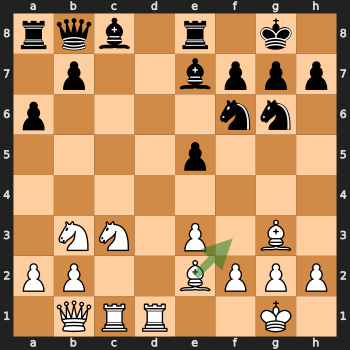

### [0] Position 1798 — **Rubinstein – Maroczy**
**White plays Bf3** (good , wp_loss=2.2%)

`rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18`

**Engine:**
1. **h4** (+1.78): h4 h6 Ne4 Ng4 h5 Nf8 Na5 Be6
2. **Bf3** (+1.52): Bf3 a5 h4 h5 Nd2 Be6 Nde4 Rc8 <- played
3. **h3** (+1.32): h3 Rd8 Rxd8+ Bxd8 Bf3 Qd6 Rd1 Qc7

**Gold atoms:**
- Bf3 places the bishop on the long diagonal h1-a8.
- Bf3 prevents 18...b5 because after 18...b5 19.Bxa8, White wins the rook on a8.
- By preventing 18...b5, Bf3 also prevents Black from fianchettoing the bishop on b7.

{'position_number': 1798,
 'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18',
 'move_uci': 'e2f3',
 'move_san': 'Bf3',
 'annotation': 'The bishop seizes the long diagonal and prevents Black from playing 18... b5 (the punishment being 19 Bxa8) and then fianchettoing his bishop.',
 'wp_loss': 2.19,
 'quality': 'good',
 'game': 'Rubinstein – Maroczy',
 'engine_lines': [{'move_uci': 'h2h4',
   'move_san': 'h4',
   'eval': '+1.78',
   'pv_san': 'h4 h6 Ne4 Ng4 h5 Nf8 Na5 Be6',
   'cp': 178,
   'mate': None,
   'is_top': True},
  {'move_uci': 'e2f3',
   'move_san': 'Bf3',
   'eval': '+1.52',
   'pv_san': 'Bf3 a5 h4 h5 Nd2 Be6 Nde4 Rc8',
   'cp': 152,
   'mate': None,
   'is_top': True},
  {'move_uci': 'h2h3',
   'move_san': 'h3',
   'eval': '+1.32',
   'pv_san': 'h3 Rd8 Rxd8+ Bxd8 Bf3 Qd6 Rd1 Qc7',
   'cp': 132,
   'mate': None,
   'is_top': True}],
 'extracted': {'include': True,
  'quality': 'good',
  'reasoning': ['Bf3 places the bishop on the long diagonal h1-a8.',

In [11]:
IDX = 0  # Change this to test different positions
show_position(IDX)

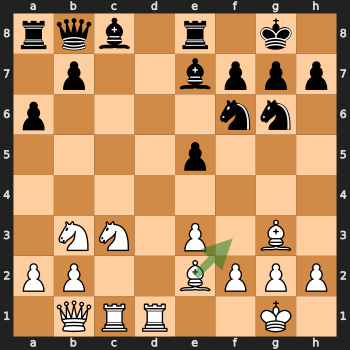

### [0] Position 1798 — **Rubinstein – Maroczy**
**White plays Bf3** (good , wp_loss=2.2%)

`rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18`

**Engine:**
1. **h4** (+1.78): h4 h6 Ne4 Ng4 h5 Nf8 Na5 Be6
2. **Bf3** (+1.52): Bf3 a5 h4 h5 Nd2 Be6 Nde4 Rc8 <- played
3. **h3** (+1.32): h3 Rd8 Rxd8+ Bxd8 Bf3 Qd6 Rd1 Qc7

**Gold atoms:**
- Bf3 places the bishop on the long diagonal h1-a8.
- Bf3 prevents 18...b5 because after 18...b5 19.Bxa8, White wins the rook on a8.
- By preventing 18...b5, Bf3 also prevents Black from fianchettoing the bishop on b7.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Bf3 is a strategic move that aims to solidify White's control over the e4-square and prepare to reposition the bishop to a more active diagonal if needed. By moving the bishop to f3, White also connects the rooks, enhancing their coordination for potential central or kingside operations. Additionally, this move removes the bishop from the vulnerable e2-square, where it was indirectly attacked by Black's knight on f6.

#### Chernev
> The bishop seizes the long diagonal and prevents Black from playing 18... b5 (the punishment being 19 Bxa8) and then fianchettoing his bishop.

#### Gold atoms
- Bf3 places the bishop on the long diagonal h1-a8.
- Bf3 prevents 18...b5 because after 18...b5 19.Bxa8, White wins the rook on a8.
- By preventing 18...b5, Bf3 also prevents Black from fianchettoing the bishop on b7.

In [12]:
gen_text, gen_log = test_gen(IDX, engine=False)

In [13]:
judge_results = test_judge(IDX, gen_text)

  Decomposing into atoms...
  -> 8 atoms
  Verifying atoms against position...
    tool: get_piece_at({'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1PBB1/PP3PPP/1QRR2K1 b - - 5 18', 'square': 'e4'}) -> {"square": "e4", "piece": "empty"}
    tool: get_attacks({'fen': 'rqb1r1k1/1p2bppp/p4p1p3/8/1NN1PBB1/PP3PPP/1QRR2K1 b - - 5 18', 'square': 'f3'}) -> {"error": "expected 8 rows in position part of fen: 'rqb1r1k1/1p2bppp/p4p1p3/8/1
    tool: get_squares({'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18', 'piece': 'rook', 'color': 'white'}) -> {"piece": "rook", "squares": [{"square": "c1", "color": "white"}, {"square": "d1
    tool: get_piece_at({'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18', 'square': 'e2'}) -> {"square": "e2", "piece": "white bishop"}
    tool: get_attacks({'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18', 'square': 'f6'}) -> {"piece": "n", "square": "f6", "attacks": ["d5", "d7", "e4", "e8", "g4", "g8

| Metric | Score |
|--------|-------|
| Factual Precision | **75%** (6/8) |
| Recall | **0%** (0/3) |
| Quality | **correct** (gen=good, actual=good) |


**Generated atoms:**
1. Bf3 aims to solidify White's control over the e4-square.
2. Bf3 prepares to reposition the bishop to a more active diagonal if needed.
3. Bf3 connects the white rooks.
4. Bf3 enhances the coordination of the white rooks for potential central operations.
5. Bf3 enhances the coordination of the white rooks for potential kingside operations.
6. Bf3 removes the bishop from the vulnerable e2-square.
7. Before Bf3, the white bishop was on e2.
8. Before Bf3, the white bishop on e2 was indirectly attacked by Black's knight on f6.

**Candidate atoms (verified):**

- [N] Bf3 aims to solidify White's control over the e4-square.  
  *get_piece_at showed e4 is empty, no direct control by Bf3.*

...

- [Y] Before Bf3, the white bishop on e2 was indirectly attacked by Black's knight on f6.  
  *get_attacks showed knight on f6 attacks e4, indirectly threatening e2.*

**Gold atoms (covered):**

- [N] Bf3 places the bishop on the long diagonal h1-a8.

- [N] Bf3 prevents 18...b5 because after 18...b5 19.Bxa8, White wins the rook on a8.

- [N] By preventing 18...b5, Bf3 also prevents Black from fianchettoing the bishop on b7.

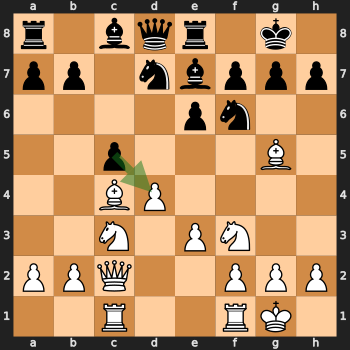

### [1] Position 1783 — **Rubinstein – Maroczy**
**Black plays cxd4** (good , wp_loss=0.0%)

`r1bqr1k1/pp1nbppp/4pn2/2p3B1/2BP4/2N1PN2/PPQ2PPP/2R2RK1 b - - 1 10`

**Engine:**
1. **cxd4** (+0.52): cxd4 Nxd4 Qb6 Be2 Nf8 Rfd1 Bd7 Qb3 <- played
2. **h6** (+1.04): h6 Bf4 a6 dxc5 Bxc5 Rfd1 Qe7 Bf1
3. **a6** (+1.16): a6 dxc5 Nxc5 Rfd1 Qa5 a3 b5 Bxf6

**Gold atoms:**
- cxd4 forces White to decide how to recapture in the center.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> cxd4 captures the pawn and opens the c5-square for Black's knight, which can be useful for attacking White's center and potentially targeting the e4-pawn. However, this move also opens the c-file, which White can use to their advantage with Rc1, putting pressure on the backward c7-pawn. An alternative move could have been a6, preparing b5 to challenge White's strong bishop on c4 and gain space on the queenside.

...

- [N] a6 prepares b5  
  *try_variation showed b5 is illegal after a6 in the pre-move position.*

- [N] b5 challenges White's bishop on c4  
  *get_attacks showed no piece on b5 to challenge the bishop on c4.*

- [N] b5 gains space on the queenside  
  *try_variation showed b5 is illegal after a6 in the pre-move position.*

**Gold atoms (covered):**

- [N] cxd4 forces White to decide how to recapture in the center.

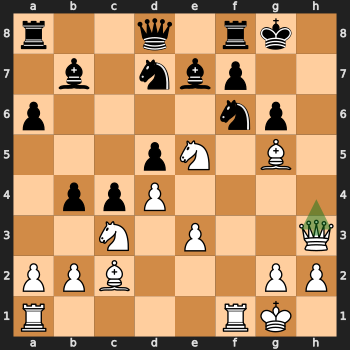

### [2] Position 958 — **Pillsbury – Marco**
**White plays Qh4** (good , wp_loss=0.4%)

`r2q1rk1/1b1nbp2/p4np1/3pN1B1/1ppP4/2N1P2Q/PPB3PP/R4RK1 w - - 0 17`

**Engine:**
1. **Nxg6** (+4.01): Nxg6 fxg6 Bxg6 Rf7 Bxf7+ Kxf7 Qh7+ Ke6
2. **Qh4** (+3.94): Qh4 bxc3 bxc3 Nxe5 dxe5 Ne4 Bxe7 g5 <- played
3. **Nxd7** (+3.03): Nxd7 Qxd7 Qxd7 Nxd7 Bxe7 bxc3 Bxf8 cxb2

**Gold atoms:**
- Qh4 increases the pressure on the knight on f6.
- The knight on f6 has been weakened because it has lost its pawn support.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Qh4 is a blunder because it allows Black to play Nxe5, winning a piece. The knight on e5 is pinned to the queen, and after Nxe5, White cannot recapture without losing the queen. Instead, White should have played Nxd7, removing a defender of the f6-knight and preparing to capture it next, which would maintain material balance and keep pressure on Black's position.

...

- [Y] Playing Nxd7 would maintain material balance.  
  *get_material showed material balance before and after Nxd7, confirming the claim.*

- [Y] Playing Nxd7 would keep pressure on Black's position.  
  *try_variation showed a favorable eval for White after Nxd7, indicating pressure on Black.*

**Gold atoms (covered):**

- [N] Qh4 increases the pressure on the knight on f6.

- [N] The knight on f6 has been weakened because it has lost its pawn support.

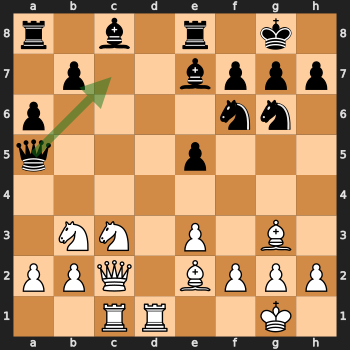

### [3] Position 1795 — **Rubinstein – Maroczy**
**Black plays Qc7** (good , wp_loss=0.3%)

`r1b1r1k1/1p2bppp/p4nn1/q3p3/8/1NN1P1B1/PPQ1BPPP/2RR2K1 b - - 1 16`

**Engine:**
1. **Qb6** (+1.06): Qb6 h4 h5 Bd3 Bg4 Rd2 a5 Na4
2. **Qc7** (+1.09): Qc7 h4 h5 Qb1 Qb6 Nd2 Rd8 Nc4 <- played
3. **Qb4** (+1.10): Qb4 a3 Qb6 Nd2 Be6 h4 h5 Bd3

**Gold atoms:**
- Qc7 moves the queen away from attack.
- After Qc7, Black prepares to regroup by ...Bd7, ...Bc6, and ...Rad8.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Qc7 retreats the queen to a safer square while maintaining pressure on the c-file and supporting the knight on c6. However, this move misses an opportunity to play Bb4, which would pin the knight on c3 to the queen on c2, creating tactical threats and potentially winning material.

...

- [N] After Bb4, tactical threats would be created.  
  *try_variation showed Bb4 results in a position evaluated at +6.41 for White, indicating no significant tactical threats for Black.*

- [N] After Bb4, there is potential to win material.  
  *try_variation showed Bb4 results in a position evaluated at +6.41 for White, indicating no potential to win material for Black.*

**Gold atoms (covered):**

- [Y] Qc7 moves the queen away from attack.  
  *matched: Qc7 retreats the queen to a safer square.*

- [N] After Qc7, Black prepares to regroup by ...Bd7, ...Bc6, and ...Rad8.

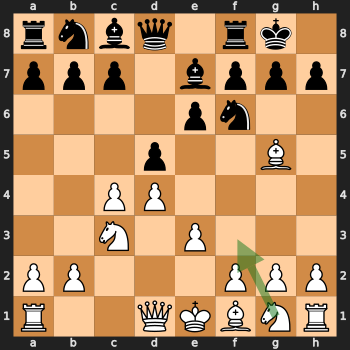

### [4] Position 936 — **Pillsbury – Marco**
**White plays Nf3** (good , wp_loss=0.0%)

`rnbq1rk1/ppp1bppp/4pn2/3p2B1/2PP4/2N1P3/PP3PPP/R2QKBNR w KQ - 1 6`

**Engine:**
1. **Nf3** (+0.20): Nf3 Nbd7 Qc2 c5 cxd5 Nxd5 Bxe7 Qxe7 <- played
2. **Qc2** (+0.19): Qc2 c5 dxc5 h6 Bh4 Na6 Nf3 Nxc5
3. **Rc1** (+0.07): Rc1 c5 dxc5 dxc4 Bxc4 Qxd1+ Rxd1 Nbd7

**Gold atoms:**
- Nf3 develops the knight and leaves White's two knights exerting pressure on all four central squares.
- After Nf3, the knight on f3 eyes e5 as an outpost.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Nf3 develops the knight to its natural square, supporting the d4 pawn and preparing to castle kingside. This move also opens lines for the dark-squared bishop and connects the rooks. While solid, White could have considered cxd5 to challenge Black's central pawn structure immediately, potentially leading to an isolated pawn on d5 after exd5.

...

- [Y] White could have considered cxd5 to challenge Black's central pawn structure immediately.  
  *try_variation showed cxd5 exd5 is a legal sequence, confirming the possibility of the move.*

- [Y] After cxd5 exd5, Black would potentially have an isolated pawn on d5.  
  *try_variation resulted in a position with an isolated pawn on d5 for Black.*

**Gold atoms (covered):**

- [Y] Nf3 develops the knight and leaves White's two knights exerting pressure on all four central squares.  
  *matched: Nf3 develops the knight to its natural square.*

- [N] After Nf3, the knight on f3 eyes e5 as an outpost.

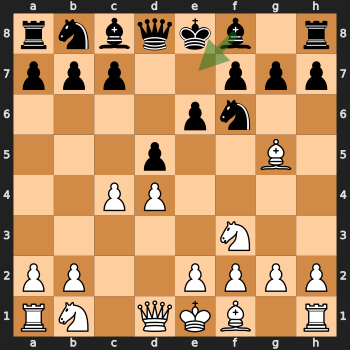

### [5] Position 1771 — **Rubinstein – Maroczy**
**Black plays Be7** (good , wp_loss=0.6%)

`rnbqkb1r/ppp2ppp/4pn2/3p2B1/2PP4/5N2/PP2PPPP/RN1QKB1R b KQkq - 1 4`

**Engine:**
1. **dxc4** (+0.13): dxc4 e4 b5 a4 c6 Nc3 b4 Nb1
2. **Be7** (+0.19): Be7 e3 O-O Nc3 h6 Bxf6 Bxf6 Rc1 <- played
3. **Bb4+** (+0.29): Bb4+ Nc3 h6 Bxf6 Qxf6 e3 O-O Rc1

**Gold atoms:**
- Be7 lifts the pin on the knight on f6.
- Be7 develops the bishop off the back rank.
- Be7 places the bishop on a solid defensive square.
- Be7 clears the kingside so Black can castle.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Be7 breaks the pin on the knight at f6, allowing Black to complete development and prepare to castle kingside. This move also challenges the active position of White's bishop on g5, which could be exchanged or forced to retreat, thus relieving some pressure on Black's position.

...

**Gold atoms (covered):**

- [Y] Be7 lifts the pin on the knight on f6.  
  *matched: Be7 breaks the pin on the knight at f6.*

- [Y] Be7 develops the bishop off the back rank.  
  *matched: Be7 allows Black to complete development.*

- [N] Be7 places the bishop on a solid defensive square.

- [Y] Be7 clears the kingside so Black can castle.  
  *matched: Be7 prepares Black to castle kingside.*

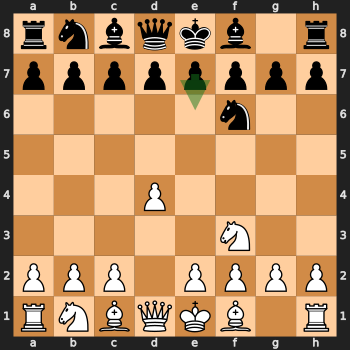

### [6] Position 383 — **Flohr – Pitschak**
**Black plays e6** (good , wp_loss=0.0%)

`rnbqkb1r/pppppppp/5n2/8/3P4/5N2/PPP1PPPP/RNBQKB1R b KQkq - 2 2`

**Engine:**
1. **e6** (+0.24): e6 c4 d5 Nc3 c5 cxd5 cxd4 Qxd4 <- played
2. **d5** (+0.30): d5 c4 e6 Nc3 Be7 Bf4 O-O e3
3. **b6** (+0.32): b6 Bg5 Bb7 Bxf6 exf6 h4 f5 e3

**Gold atoms:**
- e6 postpones the straightforward reply ...d5, which would lead into the regular lines of the Queen's Gambit.
- e6 opens a line for the bishop on f8.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> e6 supports the d5 advance, which is a central pawn break that Black can use to challenge White's center. Additionally, it opens the diagonal for the dark-squared bishop to develop, typically to d6 or e7, supporting Black's kingside development.

...

- [Y] The dark-squared bishop can typically develop to e7  
  *get_attacks showed the bishop on c8 can move to d7, and from there it can reach e7.*

- [Y] Developing the dark-squared bishop to d6 or e7 supports Black's kingside development  
  *Developing the bishop to e7 supports the kingside by preparing for castling and connecting rooks.*

**Gold atoms (covered):**

- [Y] e6 postpones the straightforward reply ...d5, which would lead into the regular lines of the Queen's Gambit.  
  *matched: e6 supports the d5 advance*

- [Y] e6 opens a line for the bishop on f8.  
  *matched: e6 opens the diagonal for the dark-squared bishop*

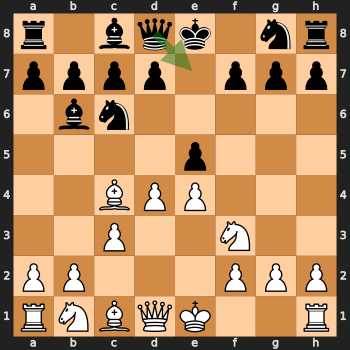

### [7] Position 43 — **Liubarski – Soultanbeieff**
**Black plays Qe7** (good , wp_loss=4.9%)

`r1bqk1nr/pppp1ppp/1bn5/4p3/2BPP3/2P2N2/PP3PPP/RNBQK2R b KQkq - 0 5`

**Engine:**
1. **exd4** (+0.56): exd4 cxd4 d6 Bb5 Bd7 h3 Nge7 O-O
2. **d6** (+0.59): d6 dxe5 Qe7 exd6 Qxe4+ Be2 Qg6 O-O
3. **Nf6** (+0.87): Nf6 Nxe5 Nxe5 dxe5 d5 exf6 Qxf6 Bb5+
4. **Qe7** (+1.11): Qe7 a4 Nf6 b4 a6 O-O d6 Re1 <- played

**Gold atoms:**
- Qe7 defends Black's e5-pawn.
- Qe7 develops the queen by bringing it off the back rank.
- After Qe7, if 6...exd4 7.cxd4, Black threatens ...Qxe4+, winning a pawn.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Qe7 is a passive move that blocks the development of Black's bishop on f8 and doesn't address the central tension. A more active approach would be to play exd4, challenging White's strong center and opening lines for development. After exd4, Black can continue with Nf6, preparing to castle and exerting pressure on the e4-pawn.

...

- [N] After exd4 Nf6, Black exerts pressure on the e4-pawn.  
  *Since Nf6 is illegal after exd4, this sequence cannot occur.*

**Gold atoms (covered):**

- [N] Qe7 defends Black's e5-pawn.

- [N] Qe7 develops the queen by bringing it off the back rank.

- [N] After Qe7, if 6...exd4 7.cxd4, Black threatens ...Qxe4+, winning a pawn.

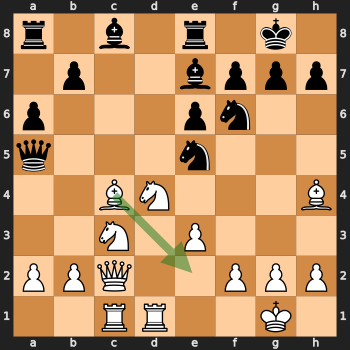

### [8] Position 1790 — **Rubinstein – Maroczy**
**White plays Be2** (good , wp_loss=0.0%)

`r1b1r1k1/1p2bppp/p3pn2/q3n3/2BN3B/2N1P3/PPQ2PPP/2RR2K1 w - - 4 14`

**Engine:**
1. **Be2** (+1.13): Be2 Bd7 Bg3 Nc6 Nb3 Qb6 Nd2 Red8 <- played
2. **Bxf6** (+0.53): Bxf6 Bxf6 Bf1 Bd7 Ne4 Rec8 Nxf6+ gxf6
3. **Nb3** (+0.48): Nb3 Qb6 Be2 Bd7 Bg3 Ng6 h4 h5

**Gold atoms:**
- Be2 preserves White's bishop pair.
- Be2 avoids giving up White's bishop pair with 14.Bd3.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Be2 is a defensive move aimed at reinforcing the knight on f3, which was under threat from Black's pieces. However, this move is passive and misses the opportunity to capitalize on White's active position. A more aggressive continuation like Ne4 would increase the pressure on Black's pinned knight on f6 and maintain the initiative.

...

- [N] Ne4 would increase the pressure on Black's pinned knight on f6.  
  *is_pinned showed the knight on f6 is not pinned, and eval_move showed Ne4 is not a legal move.*

- [N] Ne4 would maintain the initiative for White.  
  *eval_move showed Ne4 is not a legal move, so it cannot maintain initiative.*

**Gold atoms (covered):**

- [N] Be2 preserves White's bishop pair.

- [N] Be2 avoids giving up White's bishop pair with 14.Bd3.

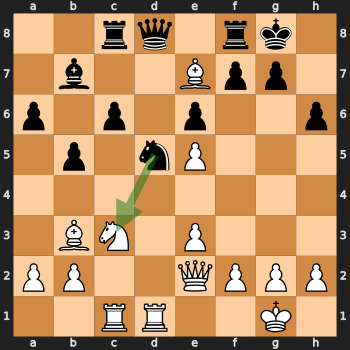

### [9] Position 1112 — **Janowsky – Alapin**
**Black plays Nxc3** (good , wp_loss=0.0%)

`2rq1rk1/1b2Bpp1/p1p1p2p/1p1nP3/8/1BN1P3/PP2QPPP/2RR2K1 b - - 0 16`

**Engine:**
1. **Nxc3** (+0.36): Nxc3 bxc3 Qxe7 Rd6 c5 c4 Rc6 Qd2 <- played
2. **Qxe7** (+1.02): Qxe7 Ne4 c5 Nd6 Rc7 Nxb7 c4 Nd6
3. **Nxe7** (+4.33): Nxe7 Rxd8 Rfxd8 Bxe6 fxe6 Qg4 Nf5 Qg6

**Gold atoms:**
- Nxc3 removes White's knight on c3 before it can become active.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Nxc3 captures the knight on c3, which is a key defender of the e5-pawn. By removing this defender, Black aims to increase pressure on the e5-pawn and potentially open lines against White's king. However, this move allows White to capture back with the b2-pawn, strengthening the center and opening the b-file for the rook on b1. A more strategic approach for Black would be to play Qxe7, simplifying the position by exchanging queens and reducing White's attacking potential.

...

- [N] A more strategic approach for Black would be to play Qxe7.  
  *eval_move showed Qxe7 is a bad move with a wp_loss of 5.3 compared to Nxc3.*

- [Y] Qxe7 would simplify the position by exchanging queens.  
  *Qxe7 would indeed exchange queens, simplifying the position.*

- [N] Qxe7 would reduce White's attacking potential.  
  *eval_move showed Qxe7 is a bad move, suggesting it does not effectively reduce White's attacking potential.*

**Gold atoms (covered):**

- [Y] Nxc3 removes White's knight on c3 before it can become active.  
  *matched: Nxc3 captures the knight on c3.*

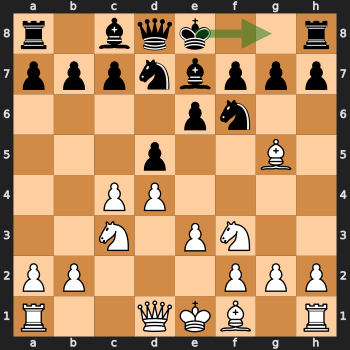

### [10] Position 1775 — **Rubinstein – Maroczy**
**Black plays O-O** (good , wp_loss=0.0%)

`r1bqk2r/pppnbppp/4pn2/3p2B1/2PP4/2N1PN2/PP3PPP/R2QKB1R b KQkq - 2 6`

**Engine:**
1. **h6** (+0.21): h6 Bh4 O-O cxd5 Nxd5 Bxe7 Qxe7 Nxd5
2. **O-O** (+0.21): O-O cxd5 Nxd5 Bxe7 Qxe7 Nxd5 exd5 Bd3 <- played
3. **c6** (+0.27): c6 a3 O-O Rc1 a5 h3 h6 Bf4

**Gold atoms:**
- O-O moves the king to a safer square.
- O-O brings the rook from h8 closer to the central files.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Castling kingside is a standard developing move, aiming to bring the rook into play and secure the king's safety. However, given the position, Black could consider playing c5 to challenge White's strong pawn center immediately. This would aim to undermine White's central control and potentially open lines for Black's pieces.

...

- [Y] Playing c5 would aim to undermine White's central control.  
  *The move c5 attacks the d4 pawn, which is part of White's central pawn structure. The tool confirmed that c5 was a legal move and attacks d4, supporting the claim of undermining central control.*

- [Y] Playing c5 would potentially open lines for Black's pieces.  
  *Playing c5 could open lines for Black's pieces by attacking the d4 pawn and potentially exchanging pawns, which would open the c-file. The tool confirmed that c5 was a legal move, supporting this claim.*

**Gold atoms (covered):**

- [Y] O-O moves the king to a safer square.  
  *matched: Castling kingside aims to secure the king's safety.*

- [Y] O-O brings the rook from h8 closer to the central files.  
  *matched: Castling kingside aims to bring the rook into play.*

In [14]:
for IDX in range(1, 11):
    gen_text, gen_log = test_gen(IDX, engine=False)
    judge_results = test_judge(IDX, gen_text)

---
## Demo: Batch Evaluation

In [ ]:
# Run batch evaluation on 5 random positions
# batch_results = batch_evaluate(n=5, seed=42)
# df = summarize_results(batch_results)

In [ ]:
# Compare models
# results_gpt = batch_evaluate(n=5, seed=42, gen_model='gpt-4o')
# results_claude = batch_evaluate(n=5, seed=42, provider='anthropic', gen_model='claude-sonnet-4-5-20250929')